# Progressive Deep Learning: From Linear to CNN

NOTE: this notebook was generated from a conversation with an AI coding assistant (Claude Code Sonnet 4.5)

**Learning Objective**: Understand the conceptual progression from simple linear models to deep convolutional networks, and learn how to collaborate with AI coding assistants to explore these ideas.

## The Conceptual Spine

1. **Linear model**: $y = \theta \cdot x$
2. **Feature engineering**: $y = \theta \cdot \phi(x)$
3. **Add nonlinearity**: $y = \sigma(\theta \cdot \phi(x))$ (GLM)
4. **Multi-layer**: $y = \sigma(W_2 \cdot \sigma(W_1 \cdot \phi(x)))$ (Neural Networks)
5. **Specialized architectures**: CNNs (spatial bias), RNNs (temporal bias)

Today we'll build all of these on MNIST and compare them.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Set seed for reproducibility
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Load MNIST Dataset

In [2]:
BATCH_SIZE = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 60000
Test samples: 10000


## Visualize Some Examples

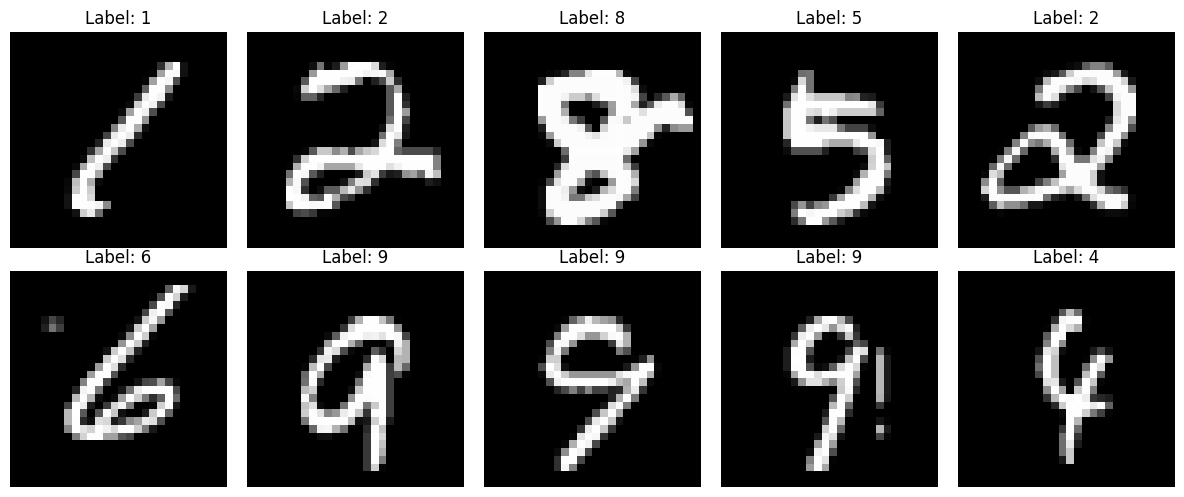

Image shape: torch.Size([1, 28, 28])
Min pixel value: -0.424
Max pixel value: 2.809


In [3]:
# Look at some examples
examples = iter(train_loader)
images, labels = next(examples)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f'Label: {labels[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Image shape: {images[0].shape}")
print(f"Min pixel value: {images[0].min():.3f}")
print(f"Max pixel value: {images[0].max():.3f}")

## Model 1: Linear Classifier

$$y = \theta \cdot x$$

Just flatten the image and apply a linear layer. No hidden layers, no nonlinearity (except the final softmax for classification).

In [4]:
class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(784, 10)  # 28x28 = 784
    
    def forward(self, x):
        x = self.flatten(x)
        return self.linear(x)

# Quick inspection
model = LinearModel()
print(model)
print(f"\nNumber of parameters: {sum(p.numel() for p in model.parameters()):,}")

LinearModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Linear(in_features=784, out_features=10, bias=True)
)

Number of parameters: 7,850


## Model 2: Multi-Layer Perceptron (MLP)

$$y = W_2 \cdot \sigma(W_1 \cdot x)$$

Add one hidden layer with ReLU activation.

In [5]:
class MLP(nn.Module):
    def __init__(self, hidden_size=128):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 10)
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

model = MLP()
print(model)
print(f"\nNumber of parameters: {sum(p.numel() for p in model.parameters()):,}")

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Number of parameters: 101,770


## Model 3: Convolutional Neural Network (CNN)

**Key idea**: Preserve spatial structure. Use weight sharing (convolutions) to encode spatial inductive bias.

Instead of flattening immediately, we apply:
- Conv layers (learn local patterns)
- Pooling (downsample while preserving important features)
- Then flatten and classify

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
    
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # 28x28 -> 14x14
        x = self.pool(self.relu(self.conv2(x)))  # 14x14 -> 7x7
        x = x.view(-1, 32 * 7 * 7)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

model = SimpleCNN()
print(model)
print(f"\nNumber of parameters: {sum(p.numel() for p in model.parameters()):,}")

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Number of parameters: 206,922


## Training Infrastructure

We need functions to train and evaluate models.

In [7]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

## Train All Three Models

Now let's train and compare them.

In [8]:
EPOCHS = 5
LEARNING_RATE = 0.001

models = {
    'Linear': LinearModel(),
    'MLP': MLP(),
    'CNN': SimpleCNN()
}

results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name}")
    print(f"{'='*60}")
    
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    train_accs = []
    test_accs = []
    
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        
        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"Train: {train_acc:.2f}% | Test: {test_acc:.2f}%")
    
    results[name] = {
        'train_acc': train_accs,
        'test_acc': test_accs,
        'final': test_acc
    }

print("\nDone!")


Training Linear
Epoch 1/5 | Train: 87.43% | Test: 91.14%
Epoch 2/5 | Train: 91.42% | Test: 91.89%
Epoch 3/5 | Train: 91.96% | Test: 91.84%
Epoch 4/5 | Train: 92.36% | Test: 91.74%
Epoch 5/5 | Train: 92.38% | Test: 92.48%

Training MLP
Epoch 1/5 | Train: 91.20% | Test: 95.03%
Epoch 2/5 | Train: 96.17% | Test: 96.38%
Epoch 3/5 | Train: 97.17% | Test: 96.92%
Epoch 4/5 | Train: 97.85% | Test: 97.23%
Epoch 5/5 | Train: 98.29% | Test: 97.41%

Training CNN
Epoch 1/5 | Train: 93.88% | Test: 97.47%
Epoch 2/5 | Train: 98.16% | Test: 98.27%
Epoch 3/5 | Train: 98.69% | Test: 98.97%
Epoch 4/5 | Train: 99.03% | Test: 98.90%
Epoch 5/5 | Train: 99.22% | Test: 99.01%

Done!


## Analyze Results

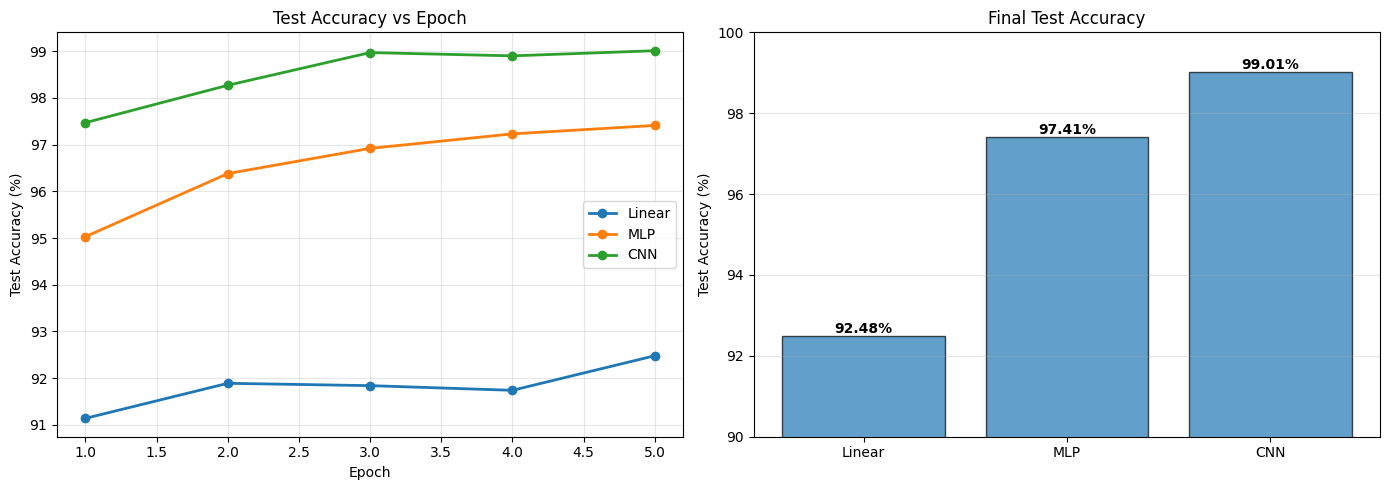

In [9]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, EPOCHS + 1)

# Test accuracy over time
ax = axes[0]
for name, data in results.items():
    ax.plot(epochs, data['test_acc'], marker='o', label=name, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy vs Epoch')
ax.legend()
ax.grid(True, alpha=0.3)

# Final comparison
ax = axes[1]
names = list(results.keys())
final_accs = [results[n]['final'] for n in names]
bars = ax.bar(names, final_accs, alpha=0.7, edgecolor='black')
for bar, acc in zip(bars, final_accs):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Final Test Accuracy')
ax.set_ylim([90, 100])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Discussion Questions

1. **Why is the linear model so good?** (>90% accuracy)
   - MNIST is quite linearly separable
   - Centered, normalized, consistent scale

2. **What does nonlinearity buy us?** (Linear → MLP)
   - ~5% improvement
   - Can learn more complex decision boundaries

3. **What does spatial structure buy us?** (MLP → CNN)
   - ~1-2% improvement
   - Preserves 2D relationships
   - Weight sharing = fewer parameters

4. **Why does CNN learn faster?**
   - Inductive bias aligned with the problem
   - Doesn't waste capacity learning "nearby pixels matter"

5. **Is this always the pattern?**
   - No! Try this on more complex datasets (CIFAR-10, ImageNet)
   - The gap between MLP and CNN grows

## Key Takeaway

**Architecture = inductive bias**

- Linear: assumes linearly separable
- MLP: assumes features are in the data (but doesn't know about spatial structure)
- CNN: assumes spatial relationships matter (translation invariance)
- RNN: assumes temporal dependencies matter
- Transformer: assumes attention-based relationships matter

Choose your architecture based on the structure of your problem.

---

# Deep Dive: Why Does Linear Work So Well?

The linear model achieved **92% accuracy** - surprisingly good for just template matching! Let's explore:

1. What does MNIST actually look like?
2. Are classes linearly separable?
3. What does the linear model learn?
4. Where does it fail?

## 1. Examining the Data Structure

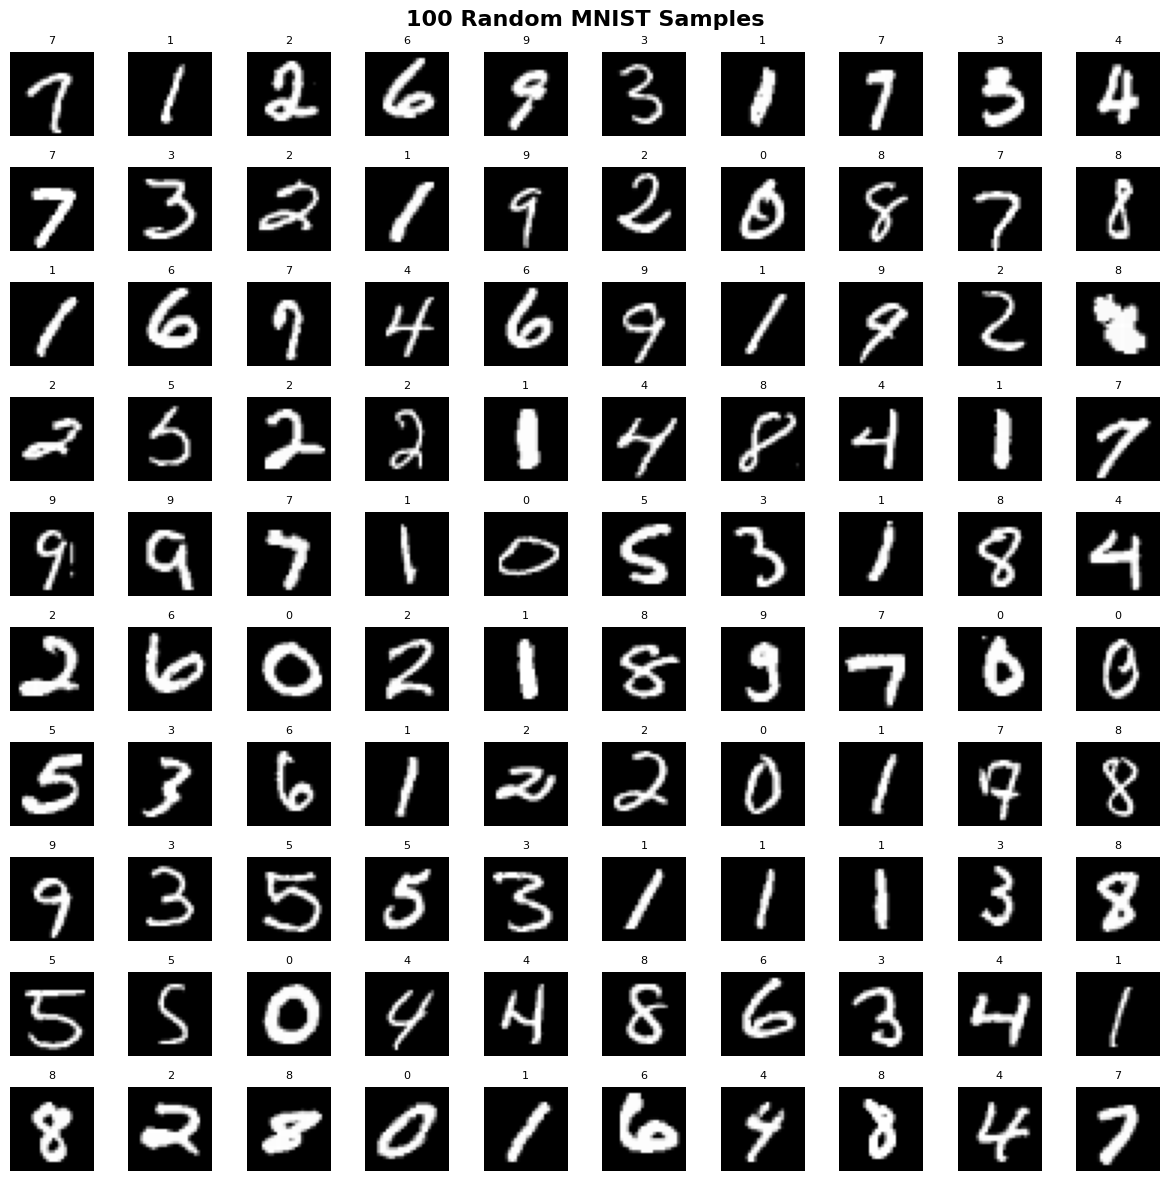


Key observations:
✓ Digits are centered and roughly same scale
✓ Background is consistent (dark)
✓ Foreground is consistent (light)
✓ Limited style variation (clean handwriting)

→ This structure makes linear separation easier!


In [10]:
# Get more diverse samples
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

data_iter = iter(train_loader)
images, labels = next(data_iter)

for i in range(10):
    for j in range(10):
        idx = i * 10 + j
        img = images[idx].squeeze() * 0.3081 + 0.1307  # Denormalize
        axes[i, j].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[i, j].set_title(f'{labels[idx].item()}', fontsize=8)
        axes[i, j].axis('off')

plt.suptitle('100 Random MNIST Samples', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("✓ Digits are centered and roughly same scale")
print("✓ Background is consistent (dark)")
print("✓ Foreground is consistent (light)")
print("✓ Limited style variation (clean handwriting)")
print("\n→ This structure makes linear separation easier!")

## 2. Visualizing in 2D: Are Classes Linearly Separable?

MNIST lives in 784 dimensions. Let's project to 2D using:
- **PCA** (linear projection) - how much structure remains?
- **t-SNE** (nonlinear projection) - for comparison

In [11]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Collect subset for visualization (t-SNE is slow)
n_samples = 2000
X_viz = []
y_viz = []

for images, labels in train_loader:
    X_viz.append(images.view(images.size(0), -1))
    y_viz.append(labels)
    if len(X_viz) * BATCH_SIZE >= n_samples:
        break

X_viz = torch.cat(X_viz, dim=0)[:n_samples].numpy()
y_viz = torch.cat(y_viz, dim=0)[:n_samples].numpy()

print(f"Projecting {n_samples} samples from 784D to 2D...")

# PCA (linear)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_viz)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.1%}")

# t-SNE (nonlinear, slow)
print("Running t-SNE (30-60 seconds)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_viz)
print("Done!")

Projecting 2000 samples from 784D to 2D...
PCA explained variance: 16.7%
Running t-SNE (30-60 seconds)...


/opt/anaconda3/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


Done!


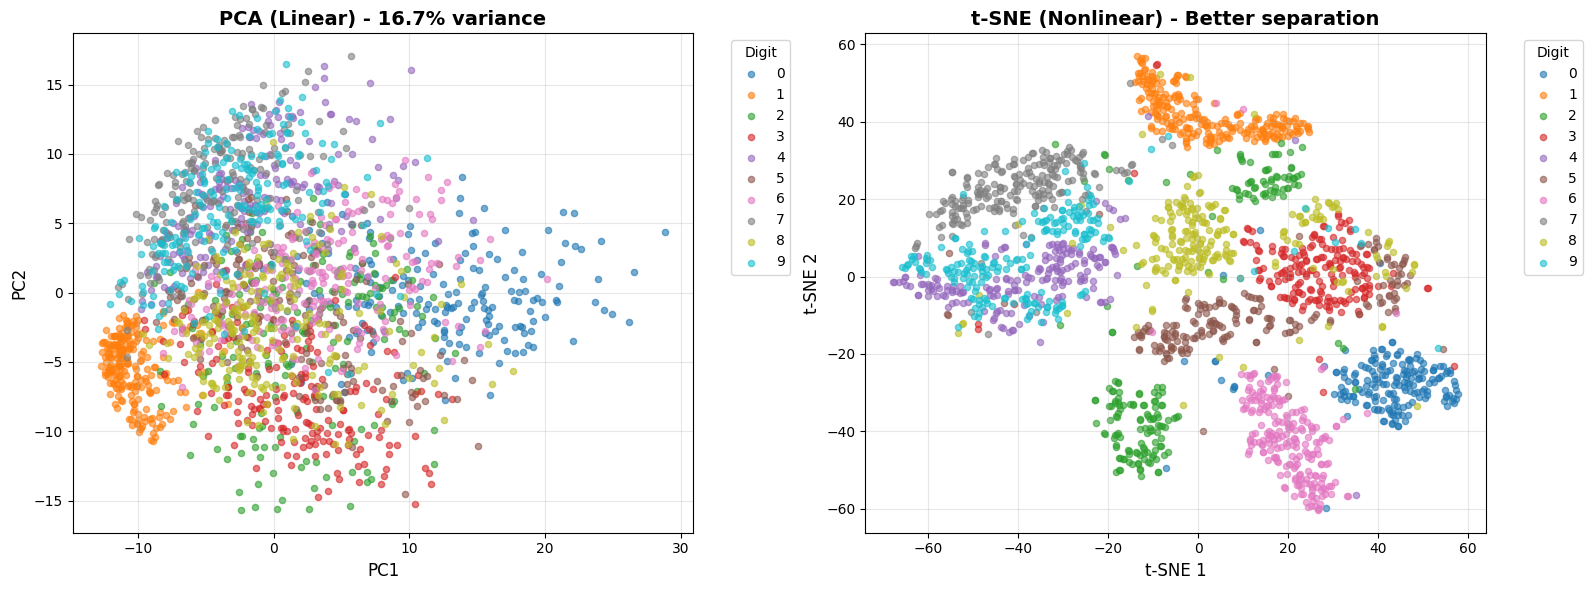


🔍 Analysis:
- PCA (linear): Classes show SOME separation even with just 2 components!
  → First 2 PCs capture ~17% of variance but reveal class structure
  → This is why linear classification works reasonably well

- t-SNE: Much better separation, but this is nonlinear
  → Shows the 'best case' if we could use perfect nonlinear features


In [12]:
# Plot both projections
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

# PCA
ax = axes[0]
for digit in range(10):
    mask = y_viz == digit
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
              c=[colors[digit]], label=str(digit), alpha=0.6, s=20)
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title(f'PCA (Linear) - {pca.explained_variance_ratio_.sum():.1%} variance',
             fontsize=14, fontweight='bold')
ax.legend(title='Digit', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# t-SNE
ax = axes[1]
for digit in range(10):
    mask = y_viz == digit
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
              c=[colors[digit]], label=str(digit), alpha=0.6, s=20)
ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title('t-SNE (Nonlinear) - Better separation',
             fontsize=14, fontweight='bold')
ax.legend(title='Digit', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔍 Analysis:")
print("- PCA (linear): Classes show SOME separation even with just 2 components!")
print("  → First 2 PCs capture ~17% of variance but reveal class structure")
print("  → This is why linear classification works reasonably well")
print("\n- t-SNE: Much better separation, but this is nonlinear")
print("  → Shows the 'best case' if we could use perfect nonlinear features")

## 3. What Does the Linear Model Learn?

A linear model learns: $y = W \cdot x + b$

For 10 classes, W is shape `(10, 784)` - one weight vector per digit.

Let's visualize these weights as images to understand what the model learned.

/var/folders/q4/_twpfpf54f3f6s17s74p67tc0000gp/T/ipykernel_42362/1578630050.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


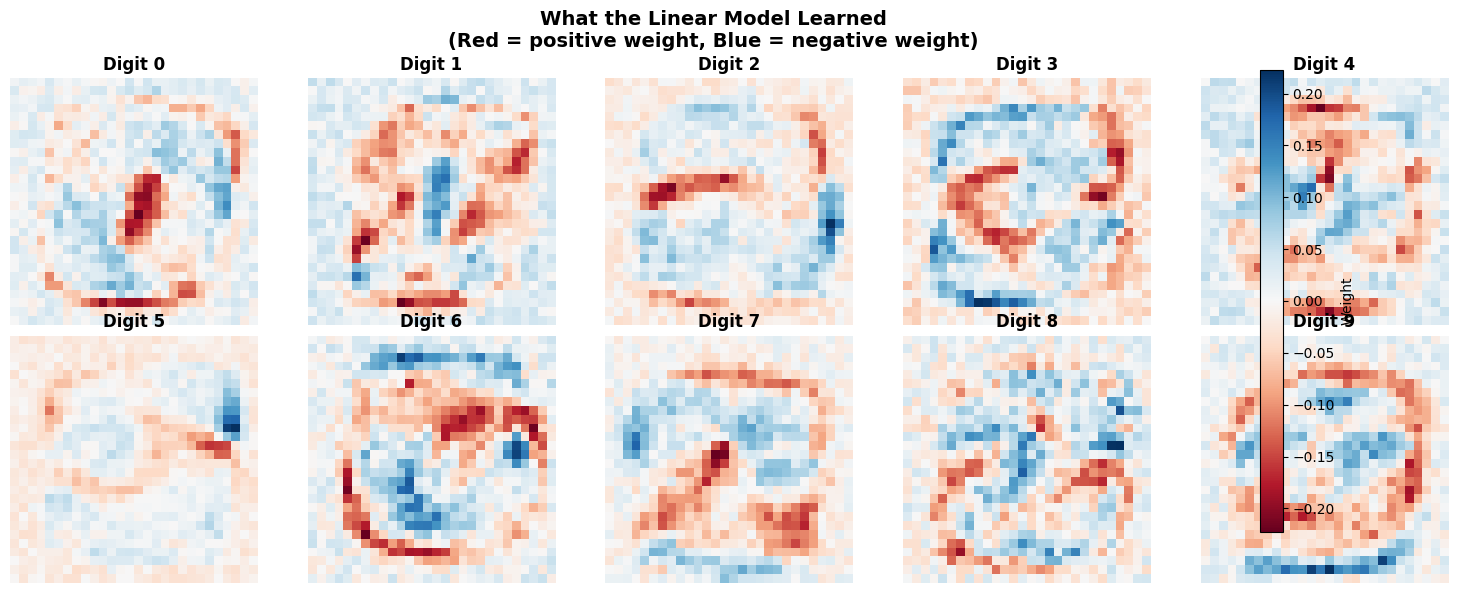


 Interpretation:
- Each digit learns a 'template' in pixel space
- Red pixels: presence INCREASES score for this digit
- Blue pixels: presence DECREASES score for this digit

Classification = argmax(W·x)
→ Which template matches the input best?

️  This is literally TEMPLATE MATCHING in pixel space!


In [13]:
# Get the trained linear model from earlier
# (If you haven't saved it, retrain quickly)
linear_model_viz = models['Linear']  # Should still be in memory

# Extract learned weights
weights = linear_model_viz.linear.weight.data.cpu().numpy()  # Shape: (10, 784)

# Visualize each class's weight vector as 28x28 image
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    weight_img = weights[i].reshape(28, 28)
    vmax = np.abs(weight_img).max()
    
    im = ax.imshow(weight_img, cmap='RdBu', vmin=-vmax, vmax=vmax)
    ax.set_title(f'Digit {i}', fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('What the Linear Model Learned\n(Red = positive weight, Blue = negative weight)',
             fontsize=14, fontweight='bold')
plt.colorbar(im, ax=axes.ravel().tolist(), label='Weight', fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print("\n Interpretation:")
print("- Each digit learns a 'template' in pixel space")
print("- Red pixels: presence INCREASES score for this digit")
print("- Blue pixels: presence DECREASES score for this digit")
print("\nClassification = argmax(W·x)")
print("→ Which template matches the input best?")
print("\n️  This is literally TEMPLATE MATCHING in pixel space!")

## 4. Visualizing Linear Decision Boundaries

Let's train a linear model on the 2D PCA projection and visualize its decision boundaries.

This shows what "linear separability" actually looks like.

In [14]:
# Simple linear model for 2D input
class LinearModel2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 10)
    def forward(self, x):
        return self.linear(x)

# Train on PCA projection
X_train_tensor = torch.FloatTensor(X_pca)
y_train_tensor = torch.LongTensor(y_viz)

model_2d = LinearModel2D().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_2d.parameters(), lr=0.01)

print("Training linear model on 2D PCA projection...")
for epoch in range(100):
    optimizer.zero_grad()
    outputs = model_2d(X_train_tensor.to(device))
    loss = criterion(outputs, y_train_tensor.to(device))
    loss.backward()
    optimizer.step()

# Check accuracy
with torch.no_grad():
    _, predicted = model_2d(X_train_tensor.to(device)).max(1)
    acc_2d = (predicted.cpu() == y_train_tensor).float().mean() * 100

print(f"Accuracy on 2D projection: {acc_2d:.2f}%")
print(f"Accuracy on full 784D: ~92%")
print(f"\n→ Higher dimensions allow MUCH better separation!")

Training linear model on 2D PCA projection...
Accuracy on 2D projection: 42.15%
Accuracy on full 784D: ~92%

→ Higher dimensions allow MUCH better separation!


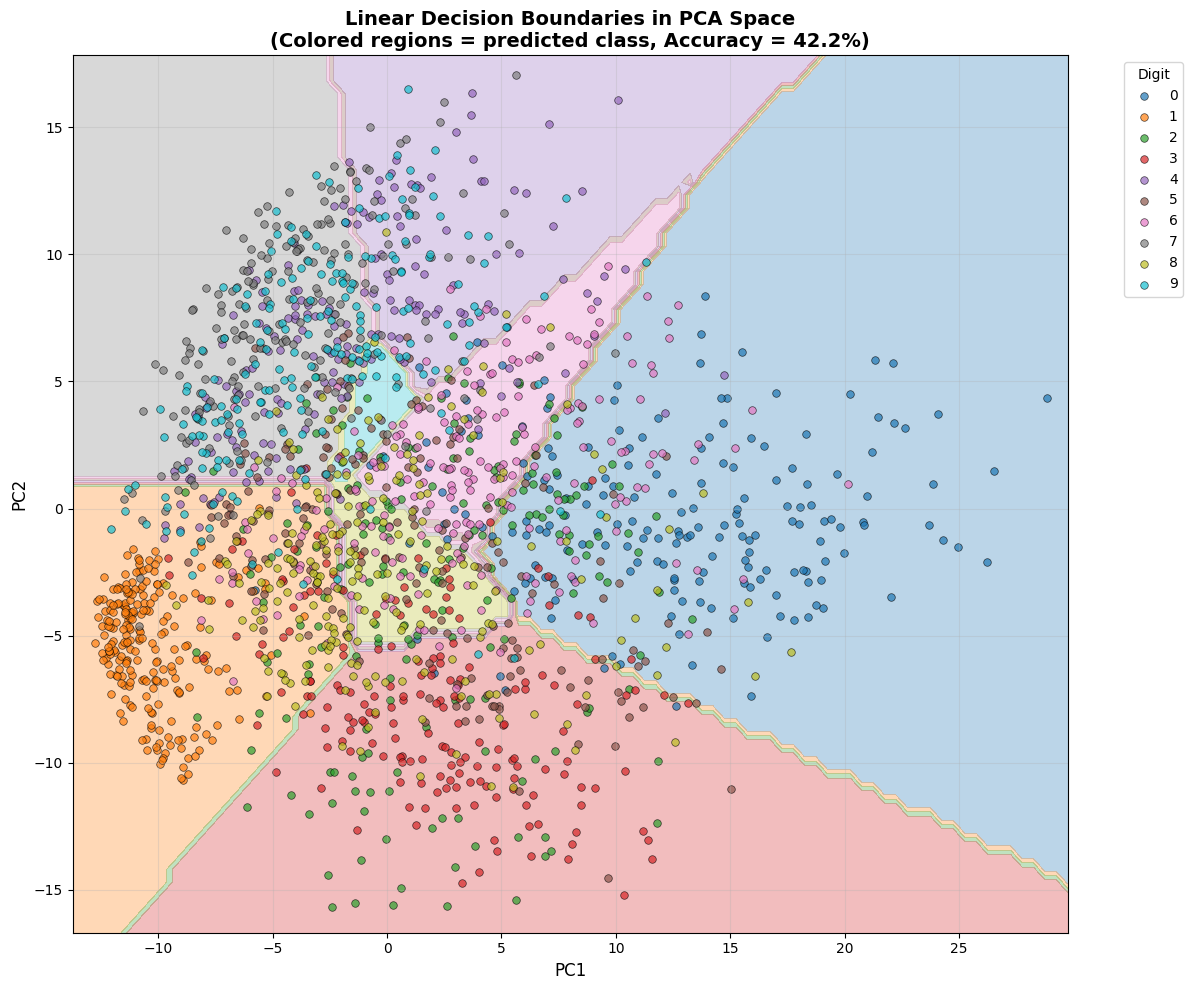


📐 Key insights:
1. Decision boundaries are LINEAR (straight lines in 2D, hyperplanes in higher D)
2. Even with just 2D, we get SOME separation
3. Look at the center - massive overlap of all classes
4. In 784D, these classes separate much better (92% vs 36%)
5. The 'curse of dimensionality' actually helps us here!


In [15]:
# Create decision boundary visualization
h = 0.5  # Mesh step size
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict on mesh
mesh_points = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)
with torch.no_grad():
    Z = model_2d(mesh_points).cpu().numpy()
    Z = np.argmax(Z, axis=1).reshape(xx.shape)

# Plot
plt.figure(figsize=(12, 10))
plt.contourf(xx, yy, Z, alpha=0.3, levels=np.arange(11) - 0.5, cmap='tab10')

# Overlay data points
for digit in range(10):
    mask = y_viz == digit
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[colors[digit]], label=str(digit), alpha=0.7, s=30,
               edgecolors='k', linewidth=0.5)

plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.title(f'Linear Decision Boundaries in PCA Space\n(Colored regions = predicted class, Accuracy = {acc_2d:.1f}%)',
         fontsize=14, fontweight='bold')
plt.legend(title='Digit', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📐 Key insights:")
print("1. Decision boundaries are LINEAR (straight lines in 2D, hyperplanes in higher D)")
print("2. Even with just 2D, we get SOME separation")
print("3. Look at the center - massive overlap of all classes")
print("4. In 784D, these classes separate much better (92% vs 36%)")
print("5. The 'curse of dimensionality' actually helps us here!")

## 5. Where Does Linear Classification Fail?

Let's examine the 8% of test cases where the linear model makes mistakes.

This reveals the **limits of template matching**.

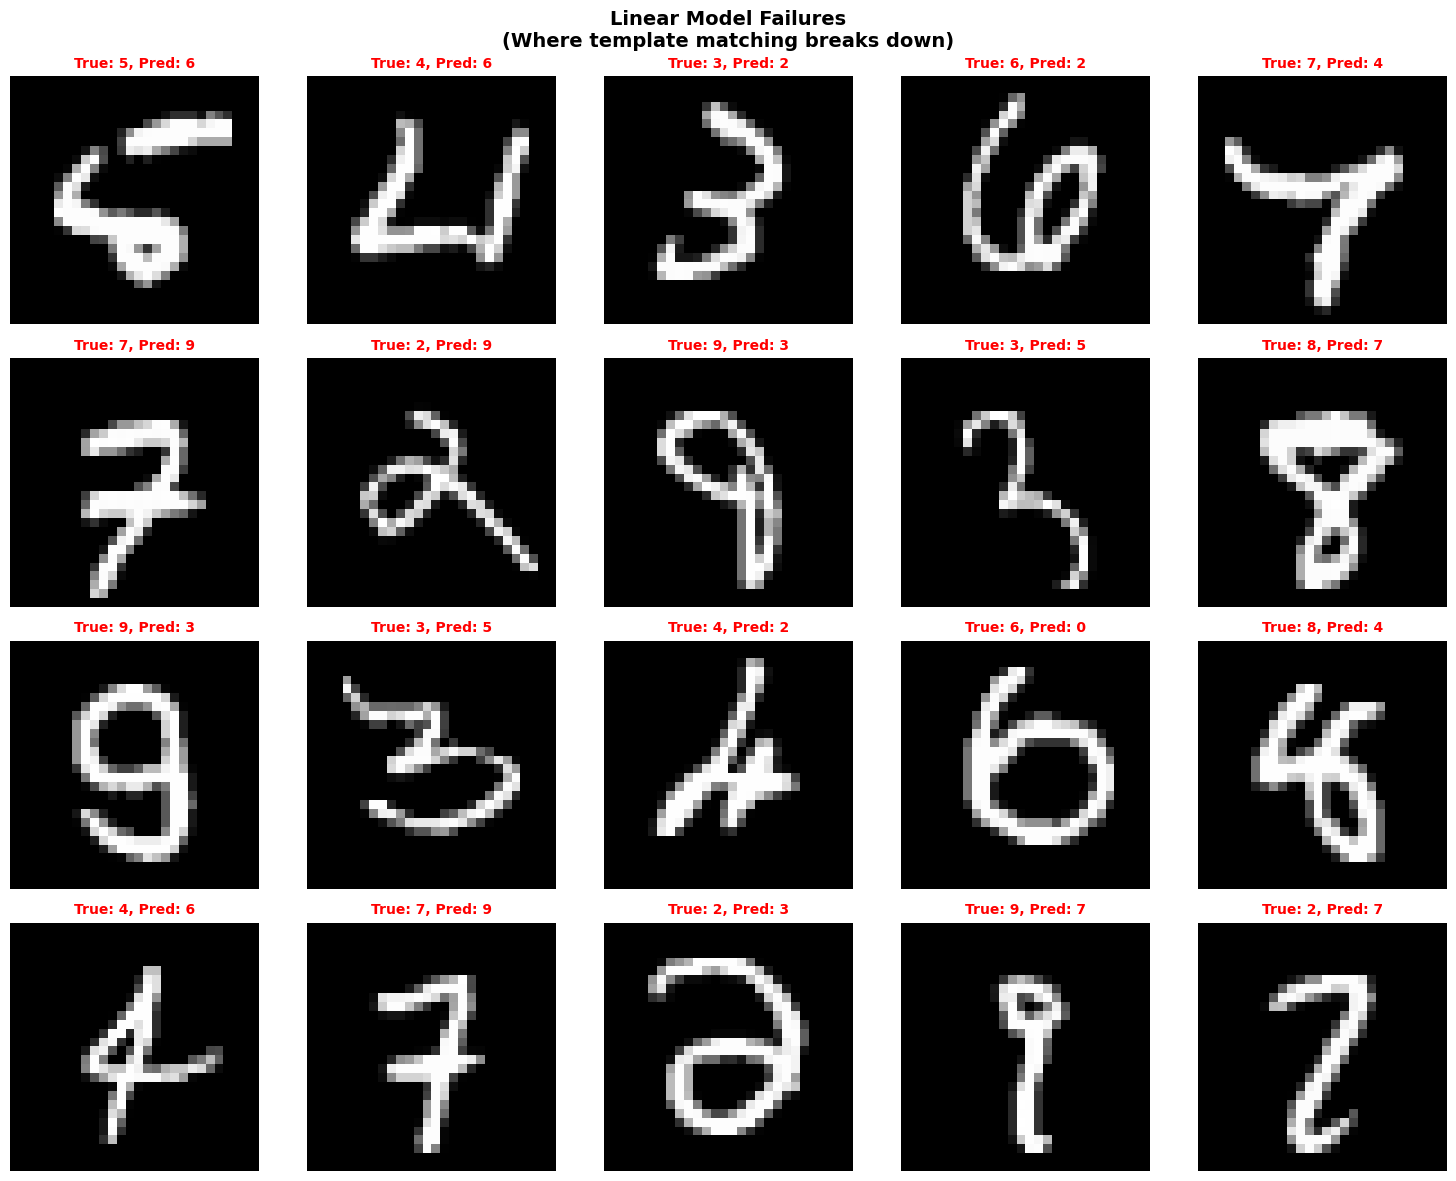


 Common failure modes:
- Ambiguous handwriting (could be multiple digits)
- Similar digits: 4/9, 3/5/8, 1/7, 6/0
- Unusual styles (too cursive, too geometric)
- Poor centering or scaling

 These are exactly where NONLINEAR models can help!
   → MLP can learn more complex decision boundaries
   → CNN can learn spatial features (not just templates)


In [16]:
# Collect misclassifications
linear_model_viz.eval()
misclassified = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = linear_model_viz(images)
        _, predicted = outputs.max(1)
        
        # Find errors
        wrong_idx = (predicted != labels).nonzero(as_tuple=True)[0]
        
        for idx in wrong_idx:
            if len(misclassified) < 20:
                misclassified.append({
                    'image': images[idx].cpu(),
                    'true': labels[idx].cpu().item(),
                    'pred': predicted[idx].cpu().item()
                })
        
        if len(misclassified) >= 20:
            break

# Visualize failures
fig, axes = plt.subplots(4, 5, figsize=(15, 12))

for i, ax in enumerate(axes.flat):
    example = misclassified[i]
    img = example['image'].squeeze() * 0.3081 + 0.1307  # Denormalize
    
    ax.imshow(img, cmap='gray')
    ax.set_title(f"True: {example['true']}, Pred: {example['pred']}",
                fontsize=10, color='red', fontweight='bold')
    ax.axis('off')

plt.suptitle('Linear Model Failures\n(Where template matching breaks down)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Common failure modes:")
print("- Ambiguous handwriting (could be multiple digits)")
print("- Similar digits: 4/9, 3/5/8, 1/7, 6/0")
print("- Unusual styles (too cursive, too geometric)")
print("- Poor centering or scaling")
print("\n These are exactly where NONLINEAR models can help!")
print("   → MLP can learn more complex decision boundaries")
print("   → CNN can learn spatial features (not just templates)")

## Summary: Why Linear Works (and Why It's Not Enough)

### Why 92% accuracy from linear classification?

1. **MNIST has good structure**
   - Centered, normalized, consistent scale
   - Classes are somewhat linearly separable
   - Even in 2D PCA, we see class separation

2. **Template matching is effective for clean data**
   - Each digit has a recognizable "prototype"
   - Most examples are close to their prototype
   - Simple dot product suffices for classification

3. **High dimensions help**
   - 784D allows much better separation than 2D
   - Linear boundaries can separate well in high-D

### Why we need nonlinearity (MLP: 97.7%, CNN: 99.0%)?

1. **Templates aren't perfect**
   - Handwriting variation exceeds template flexibility
   - Similar digits (4/9, 3/5) need complex boundaries

2. **Pixel-space features are brittle**
   - Small shifts or rotations break templates
   - Need learned features, not raw pixels

3. **Spatial structure matters**
   - Nearby pixels are related (CNNs exploit this)
   - Local patterns (edges, curves) are compositional

### The Hierarchy of Inductive Biases

- **Linear**: Assumes linearly separable in input space
- **MLP**: Assumes features exist, but doesn't know about spatial structure
- **CNN**: Assumes translation invariance and local spatial patterns

Choose your architecture based on your problem's structure!

---

## Next Steps

Try modifying this notebook:
1. Train on CIFAR-10 instead of MNIST - how does linear do?
2. Add data augmentation (rotation, translation) - how does each model handle it?
3. Visualize what CNN filters learn (edge detectors, shape detectors)
4. Try different architectures (ResNet, attention mechanisms)

The principles remain the same: **architecture = inductive bias**.

---

# Deep Dive: Convolutional Neural Networks

We saw that CNNs achieve the best performance (99%). But what exactly is a convolution, and what does the CNN learn?

## Mathematical Formulation

### Convolution Operation

A 2D convolution applies a filter (kernel) $K$ to an input image $I$ to produce a feature map $F$:

$$F[i, j] = \sum_{m=0}^{k-1} \sum_{n=0}^{k-1} I[i+m, j+n] \cdot K[m, n]$$

where:
- $I$ is the input image (e.g., 28×28)
- $K$ is the filter/kernel (e.g., 3×3)
- $F$ is the output feature map
- $(i, j)$ is the position in the output
- $(m, n)$ are offsets within the kernel

### Multi-channel Convolution

For input with $C_{in}$ channels and $C_{out}$ output channels:

$$F_{out}[i, j] = \sum_{c=0}^{C_{in}-1} \sum_{m=0}^{k-1} \sum_{n=0}^{k-1} I_c[i+m, j+n] \cdot K_{out,c}[m, n] + b_{out}$$

where:
- $I_c$ is input channel $c$
- $K_{out,c}$ is the kernel for output channel $out$, input channel $c$
- $b_{out}$ is the bias for output channel $out$

### Our CNN Architecture

```python
# Layer 1
conv1 = Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
# Input:  (batch, 1, 28, 28)
# Output: (batch, 16, 28, 28)  [16 feature maps]
# Parameters: 16 filters × (1 input channel × 3 × 3) + 16 biases = 160

pool1 = MaxPool2d(kernel_size=2, stride=2)
# Output: (batch, 16, 14, 14)  [spatial downsampling]

# Layer 2
conv2 = Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
# Input:  (batch, 16, 14, 14)
# Output: (batch, 32, 14, 14)  [32 feature maps]
# Parameters: 32 filters × (16 input channels × 3 × 3) + 32 biases = 4,640

pool2 = MaxPool2d(kernel_size=2, stride=2)
# Output: (batch, 32, 7, 7)

# Fully connected
fc1 = Linear(32*7*7, 128)  # Flatten spatial dimensions
fc2 = Linear(128, 10)      # Final classification
```

Total parameters: ~207k, but with weight sharing across spatial positions.

## 1. Extracting and Visualizing First Layer Filters

The first convolutional layer learns 16 filters, each of size 3×3.

### Filter Tensor Shape

In PyTorch, `conv1.weight` has shape `(out_channels, in_channels, height, width)`:
- `out_channels = 16` (number of filters)
- `in_channels = 1` (grayscale input)
- `height = width = 3` (kernel size)

So `conv1.weight.shape = (16, 1, 3, 3)`

Filter tensor shape: (16, 1, 3, 3)
Interpretation: (out_channels=16, in_channels=1, height=3, width=3)


/var/folders/q4/_twpfpf54f3f6s17s74p67tc0000gp/T/ipykernel_42362/1507655147.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


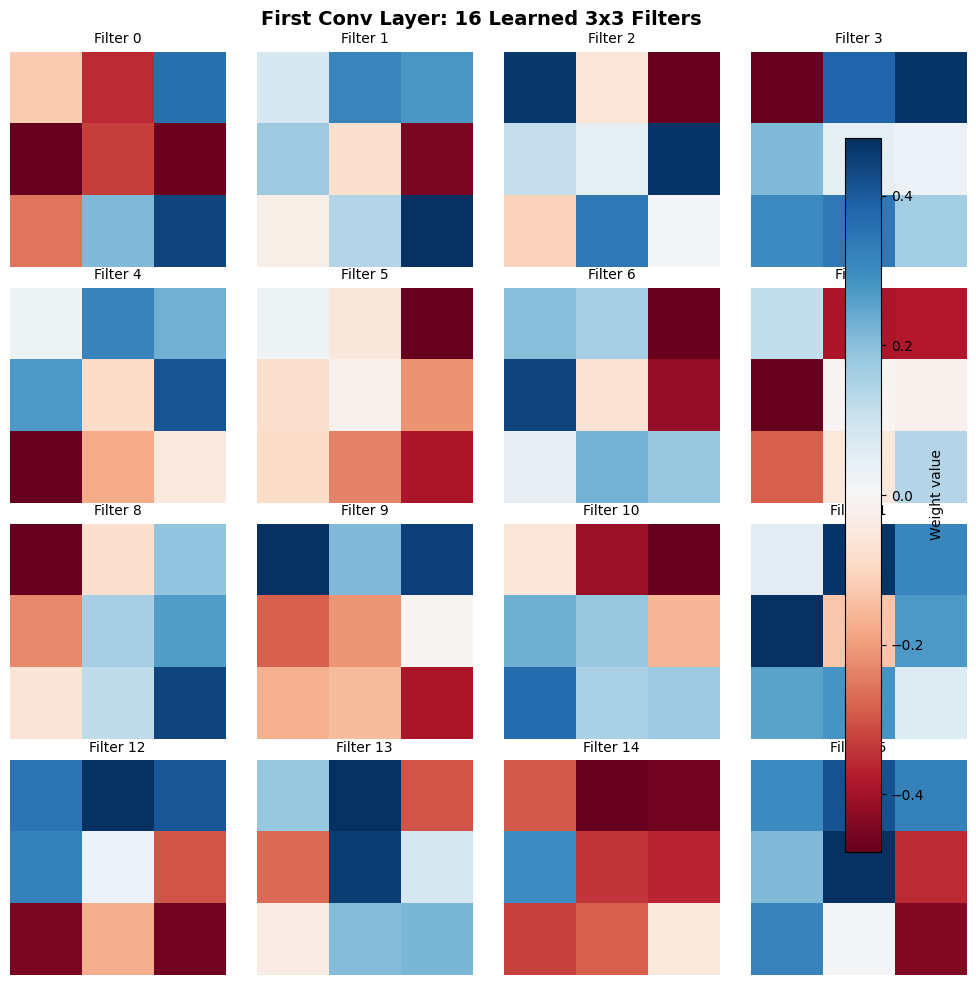

In [17]:
# Extract first layer filters
cnn_model_viz = models['CNN']
filters_layer1 = cnn_model_viz.conv1.weight.data.cpu().numpy()

print(f"Filter tensor shape: {filters_layer1.shape}")
print(f"Interpretation: (out_channels={filters_layer1.shape[0]}, "
      f"in_channels={filters_layer1.shape[1]}, "
      f"height={filters_layer1.shape[2]}, "
      f"width={filters_layer1.shape[3]})")

# For visualization, we extract each 3x3 filter
# Since in_channels=1, we can squeeze that dimension
# filters_layer1[i, 0, :, :] gives the i-th 3x3 filter

# Visualize all 16 filters
fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    # Extract i-th filter (shape: 3x3)
    filt = filters_layer1[i, 0, :, :]
    
    # Normalize for visualization (center at 0)
    vmax = np.abs(filt).max()
    
    # Plot with diverging colormap
    im = ax.imshow(filt, cmap='RdBu', vmin=-vmax, vmax=vmax, interpolation='nearest')
    ax.set_title(f'Filter {i}', fontsize=10)
    ax.axis('off')

plt.suptitle('First Conv Layer: 16 Learned 3x3 Filters',
             fontsize=14, fontweight='bold')
plt.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04, label='Weight value')
plt.tight_layout()
plt.show()

### Observations

**What are these filters detecting?**

The learned filters exhibit recognizable patterns:

- **Edge detectors**: Many filters show strong responses to edges at different orientations
  - Vertical edges: Strong blue-white-red horizontal transitions (e.g., Filter 0)
  - Horizontal edges: Strong blue-white-red vertical transitions
  - Diagonal edges: Off-diagonal patterns

- **Gradient detectors**: Smooth transitions from negative (blue) to positive (red) weights

- **Corner detectors**: Filters with localized high weights in corners

**Key insight**: The CNN automatically learned feature detectors similar to hand-crafted filters used in classical computer vision (Sobel, Gabor, etc.). This is emergent from data, not programmed.

**Translation invariance**: Each filter slides across the entire image. The same 3×3 pattern is detected at every spatial location, creating a feature map.

## 2. Computing Filter Activations on a Real Image

Let's see what happens when we pass an actual digit through the first convolutional layer.

### Forward Pass Through Conv1

For an input image $I$ of shape (1, 28, 28), the convolution produces:

$$F = \text{ReLU}(\text{Conv2d}(I))$$

Output shape: (16, 28, 28) - one 28×28 feature map per filter.

In [18]:
# Get a test image
test_iter = iter(test_loader)
test_images, test_labels = next(test_iter)

# Select example
example_idx = 0
example_img = test_images[example_idx:example_idx+1].to(device)
example_label = test_labels[example_idx].item()

print(f"Input shape: {example_img.shape}")
print(f"True label: {example_label}")

# Forward pass through first conv layer
cnn_model_viz.eval()
with torch.no_grad():
    # Step 1: Convolution
    conv1_out = cnn_model_viz.conv1(example_img)
    print(f"After Conv2d: {conv1_out.shape}")
    
    # Step 2: ReLU activation
    conv1_activated = cnn_model_viz.relu(conv1_out)
    print(f"After ReLU: {conv1_activated.shape}")

# Extract activations (remove batch dimension)
activations_layer1 = conv1_activated.cpu().numpy()[0]  # Shape: (16, 28, 28)
print(f"\nActivations shape: {activations_layer1.shape}")
print(f"Interpretation: 16 feature maps, each 28x28")

Input shape: torch.Size([1, 1, 28, 28])
True label: 7
After Conv2d: torch.Size([1, 16, 28, 28])
After ReLU: torch.Size([1, 16, 28, 28])

Activations shape: (16, 28, 28)
Interpretation: 16 feature maps, each 28x28


[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.


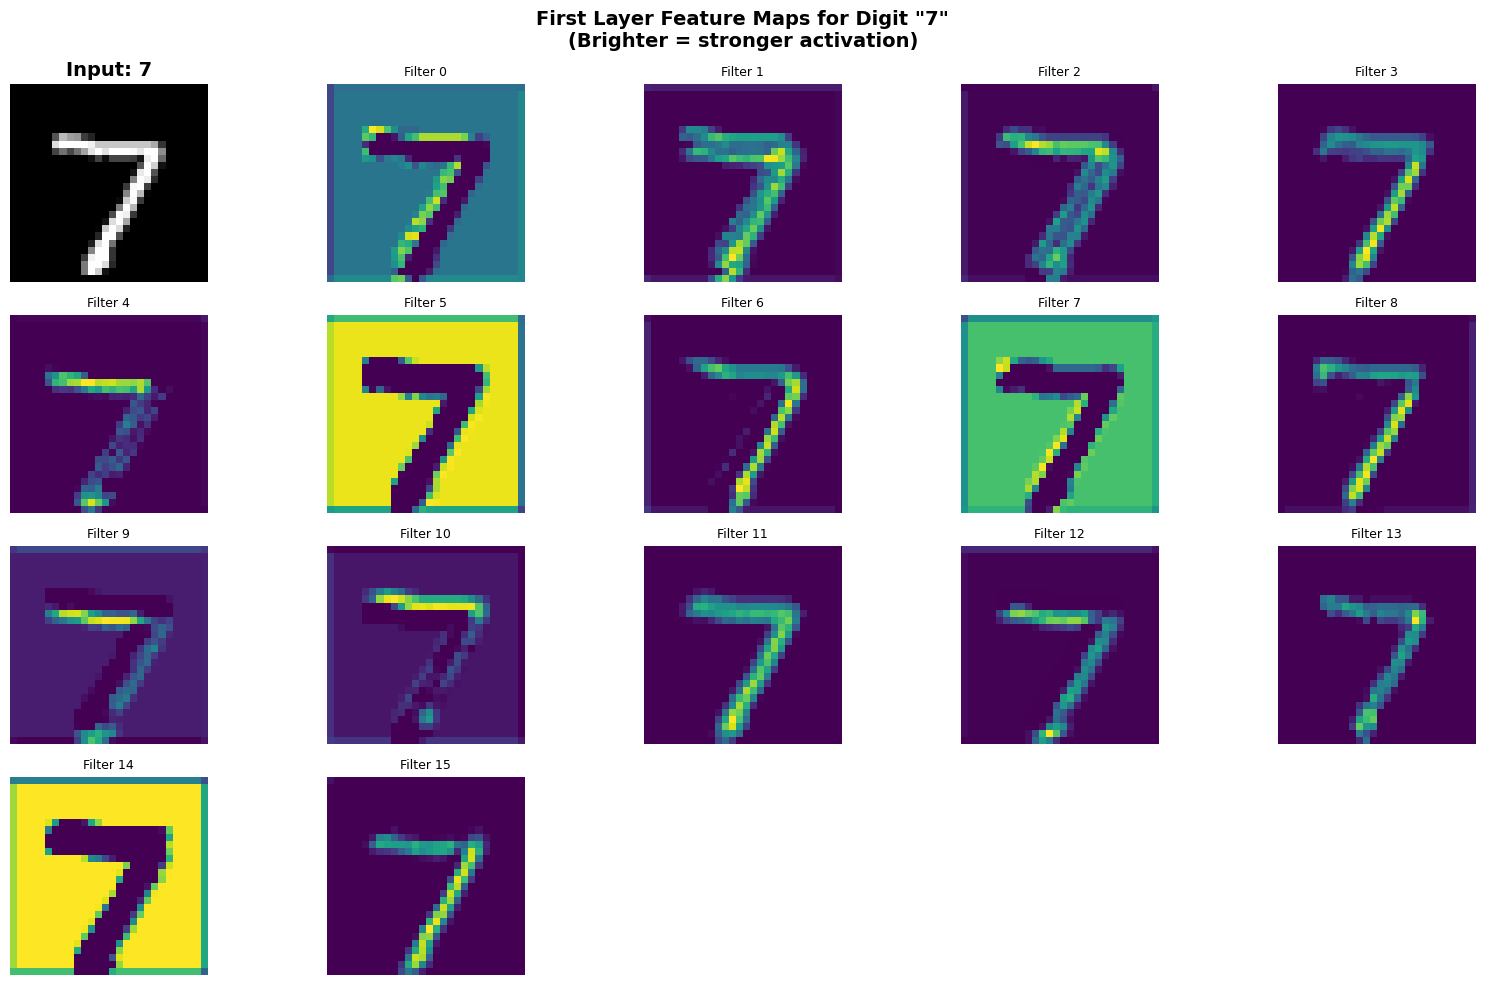

In [19]:
# Visualize input and all activations
fig = plt.figure(figsize=(16, 10))

# Show original image
ax = plt.subplot(4, 5, 1)
img_display = example_img.cpu().numpy()[0, 0] * 0.3081 + 0.1307  # Denormalize
ax.imshow(img_display, cmap='gray')
ax.set_title(f'Input: {example_label}', fontsize=14, fontweight='bold')
ax.axis('off')

# Show 16 filter activations
for i in range(16):
    ax = plt.subplot(4, 5, i+2)
    ax.imshow(activations_layer1[i], cmap='viridis')
    ax.set_title(f'Filter {i}', fontsize=9)
    ax.axis('off')

plt.suptitle(f'First Layer Feature Maps for Digit "{example_label}"\n(Brighter = stronger activation)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Observations

**Spatial activation patterns**:

- Different filters respond to different parts of the digit
- Bright regions indicate strong positive response after ReLU
- Dark regions indicate near-zero response (negative values clipped by ReLU)

**Filter specialization**:

- Some filters activate strongly on specific strokes (e.g., diagonal, horizontal)
- Some filters activate on the background (inverted response)
- Some filters show weak activation for this particular digit

**Representation as feature vector**:

The digit is now represented not as 784 pixels, but as 16 feature maps (16 × 28 × 28 = 12,544 values). After pooling, this becomes 16 × 14 × 14 = 3,136 values. The next layer will combine these features to build higher-level representations.

## 3. Second Convolutional Layer: Hierarchical Features

### Computing Second Layer Activations

The second layer takes 16 input channels (from pooled conv1 output) and produces 32 output channels:

```
conv1 → ReLU → pool (28x28 → 14x14)
  ↓
conv2 → ReLU
  ↓
32 feature maps of size 14x14
```

Each of the 32 filters in conv2 has shape (16, 3, 3) - it combines information from all 16 input channels.

In [20]:
# Forward through conv1 + pool, then conv2
with torch.no_grad():
    # Layer 1
    x = cnn_model_viz.conv1(example_img)
    x = cnn_model_viz.relu(x)
    x = cnn_model_viz.pool(x)
    print(f"After pool1: {x.shape}")
    
    # Layer 2
    x = cnn_model_viz.conv2(x)
    conv2_activated = cnn_model_viz.relu(x)
    print(f"After conv2+ReLU: {conv2_activated.shape}")

# Extract activations
activations_layer2 = conv2_activated.cpu().numpy()[0]  # Shape: (32, 14, 14)
print(f"\nLayer 2 activations: {activations_layer2.shape}")
print(f"Interpretation: 32 feature maps, each 14x14")

After pool1: torch.Size([1, 16, 14, 14])
After conv2+ReLU: torch.Size([1, 32, 14, 14])

Layer 2 activations: (32, 14, 14)
Interpretation: 32 feature maps, each 14x14


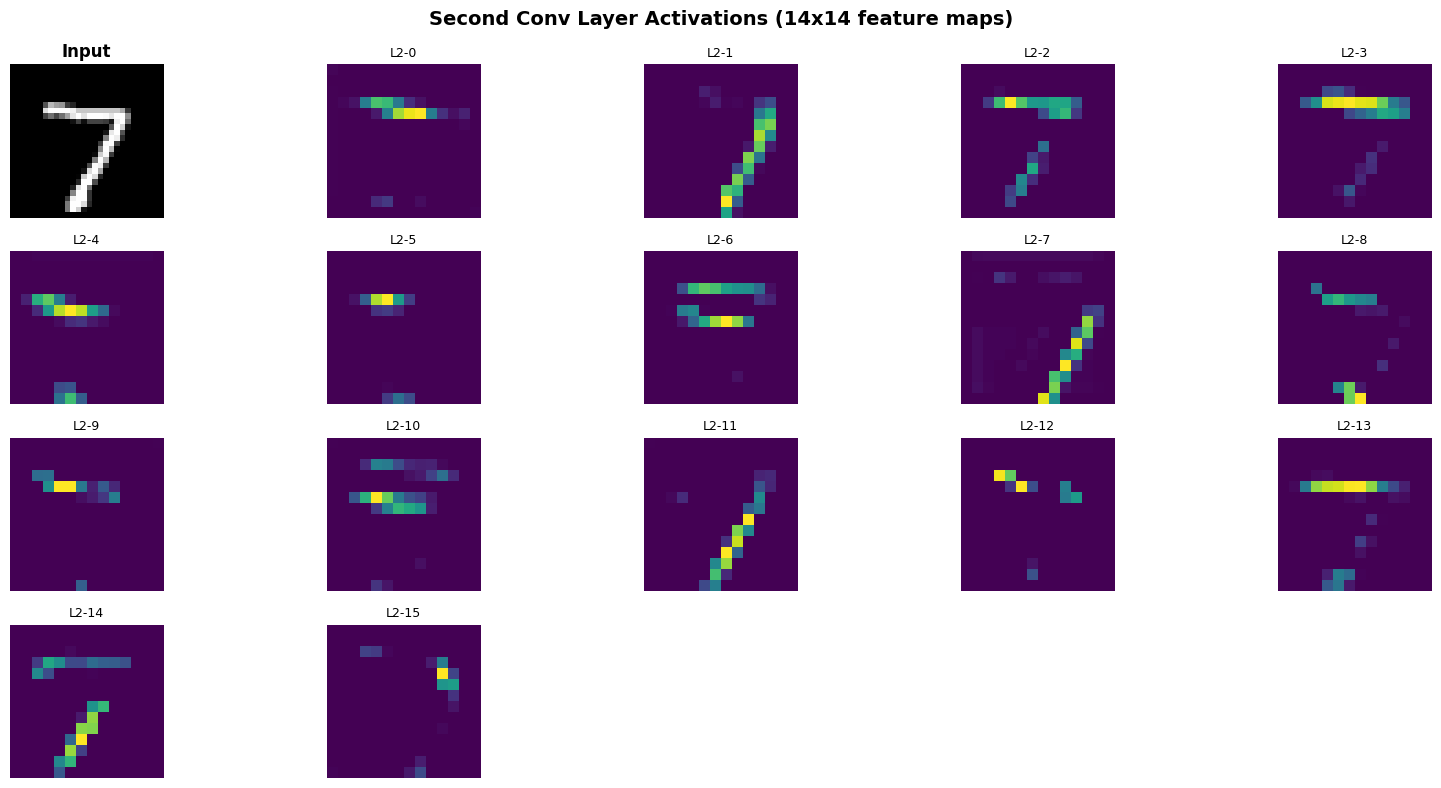

In [21]:
# Visualize input and first 16 of 32 second-layer activations
fig = plt.figure(figsize=(16, 8))

# Show input
ax = plt.subplot(4, 5, 1)
ax.imshow(img_display, cmap='gray')
ax.set_title('Input', fontsize=12, fontweight='bold')
ax.axis('off')

# Show 16 second-layer activations (out of 32 total)
for i in range(16):
    ax = plt.subplot(4, 5, i+2)
    ax.imshow(activations_layer2[i], cmap='viridis')
    ax.set_title(f'L2-{i}', fontsize=9)
    ax.axis('off')

plt.suptitle('Second Conv Layer Activations (14x14 feature maps)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Observations

**Hierarchical feature learning**:

Layer 1 (edges, gradients):
- Detects local, low-level features
- High activation across many spatial locations
- Output: 16 × 28 × 28

Pooling:
- Downsamples spatial dimensions (28 → 14)
- Provides local translation invariance
- Reduces computational cost

Layer 2 (combinations of edges):
- Combines Layer 1 features across 16 channels
- Detects curves, junctions, shape components
- More sparse activations (higher selectivity)
- Output: 32 × 14 × 14

**Compositionality**:

Each layer builds on the previous:
- Layer 1: "There is a vertical edge here"
- Layer 2: "These edges form a diagonal stroke"
- FC layers: "This combination of strokes is a 7"

This is the core idea of deep learning: hierarchical composition of features.

## 4. Comparison: Linear Model vs CNN

Let's directly compare what each model learns.

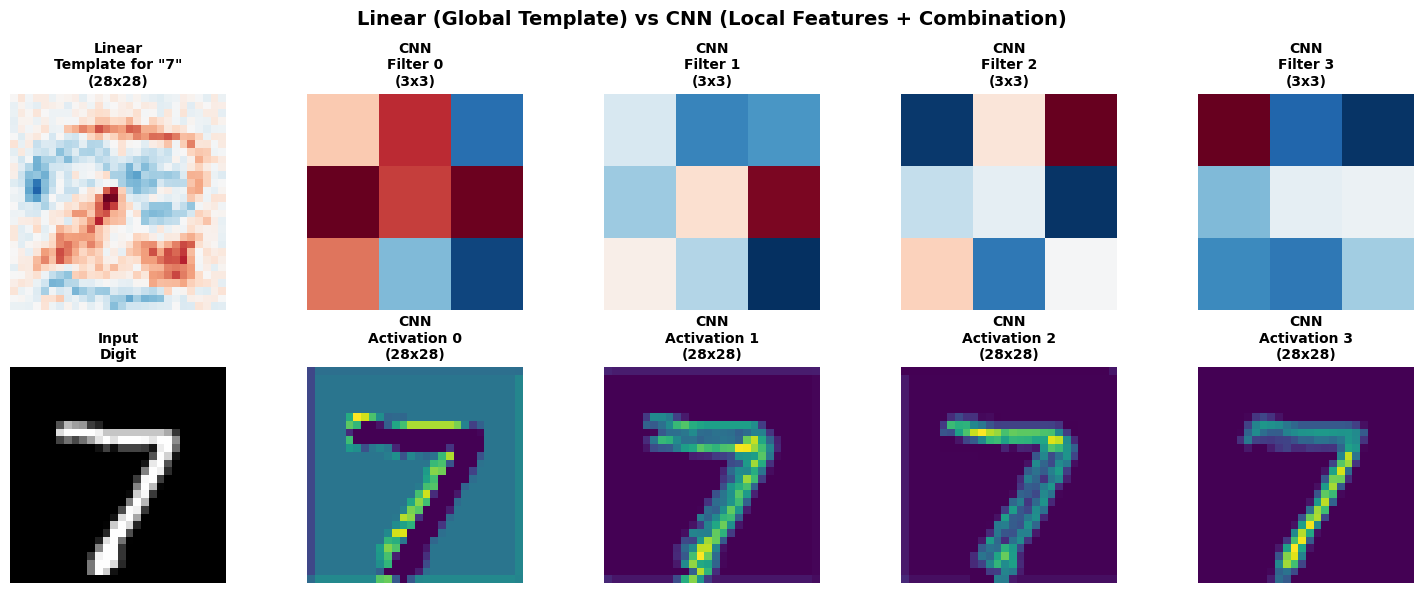

In [22]:
# Get linear model's weight vector for this digit
linear_model_viz = models['Linear']
linear_weights_all = linear_model_viz.linear.weight.data.cpu().numpy()
linear_template = linear_weights_all[example_label].reshape(28, 28)

# Create comparison visualization
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Top row: Linear template + 4 CNN filters
ax = axes[0, 0]
vmax = np.abs(linear_template).max()
ax.imshow(linear_template, cmap='RdBu', vmin=-vmax, vmax=vmax)
ax.set_title(f'Linear\nTemplate for "{example_label}"\n(28x28)', fontsize=10, fontweight='bold')
ax.axis('off')

for i in range(4):
    ax = axes[0, i+1]
    filt = filters_layer1[i, 0, :, :]
    vmax_filt = np.abs(filt).max()
    ax.imshow(filt, cmap='RdBu', vmin=-vmax_filt, vmax=vmax_filt, interpolation='nearest')
    ax.set_title(f'CNN\nFilter {i}\n(3x3)', fontsize=10, fontweight='bold')
    ax.axis('off')

# Bottom row: Input image + 4 activation maps
ax = axes[1, 0]
ax.imshow(img_display, cmap='gray')
ax.set_title('Input\nDigit', fontsize=10, fontweight='bold')
ax.axis('off')

for i in range(4):
    ax = axes[1, i+1]
    ax.imshow(activations_layer1[i], cmap='viridis')
    ax.set_title(f'CNN\nActivation {i}\n(28x28)', fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Linear (Global Template) vs CNN (Local Features + Combination)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Differences

**Linear Model**:

- Learns ONE global template per digit (28×28 weight matrix)
- Classification: $y = \text{argmax}(W \cdot x)$ where $W \in \mathbb{R}^{10 \times 784}$
- Position-dependent: pixel at (i,j) has its own unique weight
- No feature reuse: each spatial location learned independently
- Cannot handle translation or rotation well
- Parameters: 7,850 (784 × 10 + 10 biases)

**CNN**:

- Learns MANY local feature detectors (3×3 filters)
- Each filter slides across entire image (translation invariance)
- Weight sharing: same 3×3 kernel applied at every position
- Hierarchical composition: edges → shapes → objects
- Spatial downsampling through pooling (reduces dimensionality)
- Parameters: ~207k total, but many shared across positions

**Why CNN generalizes better despite more parameters**:

1. **Inductive bias**: Assumes spatial locality and translation invariance (true for images)
2. **Weight sharing**: 3×3 filter has 9 weights, but applies to all 28×28=784 positions
3. **Compositionality**: Builds complex features from simple ones (better sample efficiency)

**Parameter count comparison**:

- Linear: Every pixel gets its own weight → 784 × 10 = 7,840 parameters
- CNN conv1: 16 filters × (1 channel × 3 × 3) = 144 parameters (shared across 784 positions)
- Effective capacity is different from raw parameter count!

## Summary: Why Convolutional Neural Networks Work

### Mathematical Foundation

Convolution operation:
$$F[i, j] = \sum_{m,n} I[i+m, j+n] \cdot K[m, n]$$

Key properties:
- **Translation equivariance**: Shifting input shifts output by same amount
- **Local connectivity**: Each output depends only on local input region
- **Weight sharing**: Same kernel applied everywhere

### Architectural Principles

**Hierarchy**:
- Layer 1: Low-level features (edges, gradients)
- Layer 2: Mid-level features (curves, junctions)
- Deeper layers: High-level features (object parts)
- FC layers: Combination for classification

**Dimensionality reduction**:
- Convolution: Maintains or reduces spatial size
- Pooling: Aggressive downsampling (28×28 → 14×14 → 7×7)
- Final: Flatten to vector for classification

**Efficiency through sharing**:
- Same filter detects same feature everywhere
- Reduces parameters dramatically
- Enables learning from limited data

### When to Use CNNs

CNNs excel when data has:
- **Grid structure** (images, spectrograms, time-series with channels)
- **Spatial/temporal locality** (nearby elements are related)
- **Translation invariance** (object identity independent of position)
- **Compositional structure** (complex features built from simple ones)

### Extensions

Modern CNN architectures build on these principles:
- **ResNet**: Skip connections for very deep networks
- **Inception**: Multiple filter sizes in parallel
- **DenseNet**: Dense connections between layers
- **U-Net**: Encoder-decoder for segmentation

But the core idea remains: **local features + weight sharing + hierarchical composition**.